# HyperParameterOptimisation for Approval Predict

## Objectives
* Optimise the hyperparameters using AdaBoost, RandomForest, XGBoost, and LogisticRegression classifiers
* Apply feature engineering (BoxCox transformation and RobustScaler) to improve model performance
* Achieve 80%+ recall and precision on test set
* Select best model for deployment

## Inputs
* outputs/datasets/collection/loan_approval.csv

## Outputs
* Optimised LogisticRegression model achieving 88% recall and 86% precision on test set
* Comparative analysis of all models showing LogisticRegression has minimal overfitting

## Additional Information
Features used: `credit_score`, `years_employed`, `loan_amount`, `income`, `loan_to_income`

The `points` feature was excluded as it showed 100% prediction accuracy in previous notebooks before going through an ML pipeline.

## Imports

In [1]:
import os
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from feature_engine.transformation import BoxCoxTransformer
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
sns.set(style="whitegrid")
warnings.filterwarnings("ignore")

## Update Working Directory

Set the working directory to the project root for consistent file path access.

In [2]:
current_dir = os.getcwd()
current_dir

'/Users/davidcarr/Desktop/vscode-projects/Approval_Predict/jupyter_notebooks'

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [4]:
current_dir = os.getcwd()
current_dir

'/Users/davidcarr/Desktop/vscode-projects/Approval_Predict'

## Load data

We loaded the dataset and prepared it with the following steps:
* Convert target variable `loan_approved` from boolean to integer
* Create `loan_to_income` feature (loan_amount / income)
* Select features: `credit_score`, `years_employed`, `loan_amount`, `income`, `loan_to_income`

In [5]:
root = current_dir
file_path = (
    Path(root)
    / "outputs"
    / "datasets"
    / "collection"
    / "loan_approval.csv"
)

if not file_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {file_path}"
    )

df = pd.read_csv(file_path).drop(['name', 'city'], axis=1)
df['loan_approved'] = df['loan_approved'].astype(int)
df['loan_to_income'] = df['loan_amount'] / df['income']

reduced_features = [
    "credit_score",
    "years_employed",
    "loan_amount",
    "income",
    "loan_to_income",
]
X = df[reduced_features].copy()
y = df['loan_approved'].copy()

X.head(3), y.head(3)

(   credit_score  years_employed  loan_amount  income  loan_to_income
 0           389              27        39698  113810        0.348809
 1           729              28        15446   44592        0.346385
 2           584              13        11189   33278        0.336228,
 0    0
 1    0
 2    0
 Name: loan_approved, dtype: int64)

## Split train and test sets

We split the dataset into training (80%) and test (20%) sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Train/Test Shapes:")
X_train.shape, y_train.shape, X_test.shape, y_test.shape

Train/Test Shapes:


((1600, 5), (1600,), (400, 5), (400,))

## Handle Class Imbalance

Apply SMOTE (Synthetic Minority Over-sampling Technique) to balance the training data:
* Addresses class imbalance in `loan_approved` target variable
* Creates synthetic samples of minority class (Approved loans)

After SMOTE: (1808, 5) (1808,)


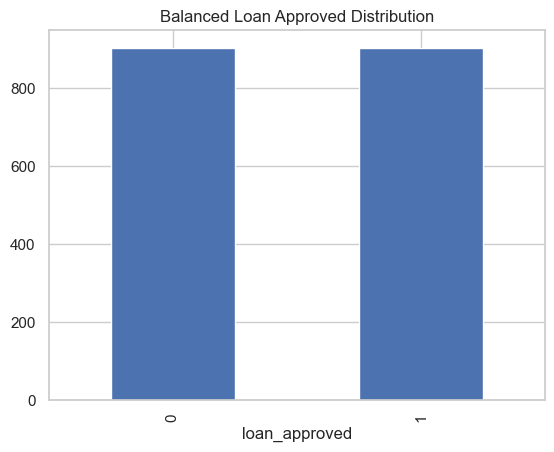

In [7]:
smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.shape)

y_train_bal.value_counts().plot(
    kind="bar",
    title="Balanced Loan Approved Distribution",
)
plt.show()

## ML Pipeline

## Pipeline Structure

All classifiers use the PipelineClf() function with the following:

1. **BoxCoxTransformer**: Normalises `loan_to_income` (handles skewness and 5.75% outliers identified in Data Exploration)
2. **RobustScaler**: Scales all features
3. **Classifier**: The model being optimised

In [8]:
def PipelineClf(model):
    """
    Builds a pipeline for hyperparameter optimisation with feature engineering.
    Pipeline steps:
    1. BoxCox transformation for loan_to_income (handles skewness and outliers)
    2. RobustScaler for all features (robust to outliers)
    3. Model classifier
    """
    return Pipeline([
        ("boxcox", BoxCoxTransformer(variables=['loan_to_income'])),
        ("scaler", RobustScaler()),
        ("model", model)
    ])

## HyperParameter Optimisation

A custom class, HyperparameterOptimizationSearch, was created by the CodeInstitute to perform grid searches across selected parameter spaces for each model.

In [9]:
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")

            model = PipelineClf(self.models[key])
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring, )
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = ['estimator', 'min_score',
                   'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches

The 2 functions below provide reporting of performance metrics (accuracy, precision, recall, and F1-score). They will give a comparison between the classifiers AdaBoost, RandomForest, XGBoost and LogisticRegression.

In [10]:
def confusion_matrix_and_report(X, y, pipeline, label_map):
    prediction = pipeline.predict(X)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        confusion_matrix(y_true=prediction, y_pred=y),
        columns=[["Actual " + sub for sub in label_map]],
        index=[["Prediction " + sub for sub in label_map]]
    ))
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")


def clf_performance(X_train, y_train, X_test, y_test, pipeline, label_map):
    print("#### Train Set #### \n")
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map)

    print("#### Test Set ####\n")
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map)

## First round of hyperparameter optimisation starting with AdaBoostClassifier

### Initial Parameter Search

Testing baseline hyperparameter combinations for AdaBoost to identify promising parameter ranges.

In [11]:
model = {"AdaBoostClassifier": AdaBoostClassifier(random_state=42)}

**Parameter Grid:**
* **n_estimators**: [50, 25, 80, 150] - Number of boosting iterations
* **learning_rate**: [1, 0.1, 2] - Weight contribution of each iteration

*Reference: [Parameters](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)*

Hyparameter values were taken from CodeInstitute Scikit-Learn Unit 6: Cross Validation Search Part 2. This was recommended as a starting point and as a reference for this Project.

In [12]:
params_search_ada = {
    "AdaBoostClassifier": {
        "model__n_estimators": [50,25,80,150],
        "model__learning_rate": [1,0.1, 2]
    }
}

### Execute Grid Search

Find the best performing parameters from grid search.

In [13]:
search = HyperparameterOptimizationSearch(
    models=model,
    params=params_search_ada,
)
search.fit(X_train_bal, y_train_bal,
           scoring=make_scorer(recall_score, pos_label=1),
           cv=5, n_jobs=-1)


Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [14]:
extensive_grid_search_summary, extensive_grid_search_pipelines = (
    search.score_summary(sort_by="mean_score")
)

best_model = extensive_grid_search_summary.iloc[0, 0]

best_parameters = extensive_grid_search_pipelines[best_model].best_params_

classification_pipeline = (
    extensive_grid_search_pipelines[best_model].best_estimator_
)

best_parameters

{'model__learning_rate': 1, 'model__n_estimators': 80}

### Review Performance

Review train and test set performance to assess baseline model quality.


In [15]:
clf_performance(X_train=X_train_bal, y_train=y_train_bal,
                X_test=X_test, y_test=y_test,
                pipeline=classification_pipeline,
                label_map=["Rejected", "Approved"])

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             898               4
Prediction Approved               6             900


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       904
    Approved       0.99      1.00      0.99       904

    accuracy                           0.99      1808
   macro avg       0.99      0.99      0.99      1808
weighted avg       0.99      0.99      0.99      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             213               5
Prediction Approved               4             178


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.98      0.98      0.98       217
    Approved       0.98      0.97      0.98       183

    accuracy                   

### Refined Parameter Search

Adjust parameter ranges based on initial results to find optimal hyperparameters.


In [16]:
params_search_ada = {
    "AdaBoostClassifier": {
        "model__n_estimators": [10,25,80,150],
        "model__learning_rate": [1,0.5, 2]
    }
}

### Execute Grid Search

In [17]:
search = HyperparameterOptimizationSearch(
    models=model,
    params=params_search_ada,
)
search.fit(X_train_bal, y_train_bal,
           scoring=make_scorer(recall_score, pos_label=1),
           cv=5, n_jobs=-1)


Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [18]:
extensive_grid_search_summary, extensive_grid_search_pipelines = (
    search.score_summary(sort_by="mean_score")
)

best_model = extensive_grid_search_summary.iloc[0, 0]

best_parameters = extensive_grid_search_pipelines[best_model].best_params_

classification_pipeline = (
    extensive_grid_search_pipelines[best_model].best_estimator_
)

best_parameters

{'model__learning_rate': 0.5, 'model__n_estimators': 150}

In [19]:
clf_performance(X_train=X_train_bal, y_train=y_train_bal,
                X_test=X_test, y_test=y_test,
                pipeline=classification_pipeline,
                label_map=["Rejected", "Approved"])

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             895               2
Prediction Approved               9             902


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       904
    Approved       0.99      1.00      0.99       904

    accuracy                           0.99      1808
   macro avg       0.99      0.99      0.99      1808
weighted avg       0.99      0.99      0.99      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             213               3
Prediction Approved               4             180


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.99      0.98      0.98       217
    Approved       0.98      0.98      0.98       183

    accuracy                   

### Create Final AdaBoost Model

* Define optimised AdaBoost model with best parameters found from grid searches.
* Create pipeline with BoxCoxTransformer and RobustScaler.


In [20]:
ada_best = AdaBoostClassifier(
    learning_rate=0.5,
    n_estimators=150,
    random_state=42
)


In [21]:
pipeline_ada = Pipeline([
    ("boxcox", BoxCoxTransformer(variables=['loan_to_income'])),
    ("scaler", RobustScaler()),
    ("model", ada_best)
])

In [22]:
pipeline_ada.fit(X_train_bal, y_train_bal)

,steps,"[('boxcox', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,variables,['loan_to_income']
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,estimator,None


### AdaBoost Best Parameter Evaluation 

In [23]:
y_pred_train = pipeline_ada.predict(X_train_bal)
y_pred_test = pipeline_ada.predict(X_test)

print("#### Train Set ####\n")
print(confusion_matrix(y_train_bal, y_pred_train))
print(
    classification_report(
        y_train_bal,
        y_pred_train,
        target_names=["Rejected", "Approved"],
    )
)

print("#### Test Set ####\n")
print(confusion_matrix(y_test, y_pred_test))
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["Rejected", "Approved"],
    )
)

#### Train Set ####

[[895   9]
 [  2 902]]
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       904
    Approved       0.99      1.00      0.99       904

    accuracy                           0.99      1808
   macro avg       0.99      0.99      0.99      1808
weighted avg       0.99      0.99      0.99      1808

#### Test Set ####

[[213   4]
 [  3 180]]
              precision    recall  f1-score   support

    Rejected       0.99      0.98      0.98       217
    Approved       0.98      0.98      0.98       183

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



### Findings
Overall hyperparameter optimisation using AdaBoost found similar findings to the baseline values. There appears to be a very high precision and recall value for both train and test sets. The confusion matrix shows the model is catching both rejections and approvals with very few mistakes. However, this finding could suggest the model is memorising the data and favouring the `credit_score` feature. This may be due to a small data set and credit score having a high predictive power. However, testing with credit score removed caused lower test set scores around 0.60-0.66 with hyperparameter optimisation. Therefore, we will try another classifier.

## RandomForestClassifier Optimisation

### Initial Parameter Search

Testing baseline hyperparameter combinations for RainForestClassifier.

In [24]:
model = {"RandomForestClassifier": RandomForestClassifier(random_state=42)}

### Initial Parameter Search

**Parameter Grid:**
* **n_estimators**: [100, 50, 140] - Number of trees in the forest. Therefore, a higher number of trees increases the performance and makes the predictions more stable
* **max_depth**: [None, 4, 15] - Maximum tree depth
* **min_samples_split**: [2, 50] - Minimum samples to split node
* **min_samples_leaf**: [1, 50] - Minimum samples in leaf node
* **max_leaf_nodes**: [None, 50] - Maximum leaf nodes

*Reference: [Parameter reference 1](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html?utm_source=chatgpt.com)*

*Reference: [Parameter reference 2](https://builtin.com/data-science/random-forest-algorithm)*

Hyparameter values were taken from CodeInstitute Scikit-Learn Unit 6: Cross Validation Search Part 2.

In [25]:
params_search = {
    "RandomForestClassifier": {
        'model__n_estimators': [100,50,140],
        'model__max_depth': [None,4, 15],
        'model__min_samples_split': [2,50],
        'model__min_samples_leaf': [1,50],
        'model__max_leaf_nodes': [None,50],
    },
}

### Execute Gridsearch
This search will find the best hyperparameters.

In [26]:
search = HyperparameterOptimizationSearch(models=model, params=params_search)
search.fit(X_train_bal, y_train_bal,
           scoring=make_scorer(recall_score, pos_label=1),
           cv=5, n_jobs=-1)


Running GridSearchCV for RandomForestClassifier 

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [27]:
extensive_grid_search_summary, extensive_grid_search_pipelines = (
    search.score_summary(sort_by="mean_score")
)

best_model = extensive_grid_search_summary.iloc[0, 0]

best_parameters = extensive_grid_search_pipelines[best_model].best_params_

classification_pipeline = (
    extensive_grid_search_pipelines[best_model].best_estimator_
)

best_parameters

{'model__max_depth': None,
 'model__max_leaf_nodes': None,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

In [28]:
clf_performance(X_train=X_train_bal, y_train=y_train_bal,
                X_test=X_test, y_test=y_test,
                pipeline=classification_pipeline,
                label_map=["Rejected", "Approved"])

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             904               0
Prediction Approved               0             904


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       904
    Approved       1.00      1.00      1.00       904

    accuracy                           1.00      1808
   macro avg       1.00      1.00      1.00      1808
weighted avg       1.00      1.00      1.00      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             214               4
Prediction Approved               3             179


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.98      0.99      0.98       217
    Approved       0.98      0.98      0.98       183

    accuracy                   

### Create Final RandomForestClassifier Model

* Define optimised RandomForestClassifier model with best parameters found from grid searches.
* Create pipeline with BoxCoxTransformer and RobustScaler.

In [29]:
rf_best = RandomForestClassifier(
    max_depth=None,
    max_leaf_nodes=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)


In [30]:
pipeline_rf = Pipeline([
    ("boxcox", BoxCoxTransformer(variables=['loan_to_income'])),
    ("scaler", RobustScaler()),
    ("model", rf_best)
])

In [31]:
pipeline_rf.fit(X_train_bal, y_train_bal)

,steps,"[('boxcox', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,variables,['loan_to_income']
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,n_estimators,100


In [32]:
clf_performance(
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    pipeline=pipeline_rf,
    label_map=["Rejected", "Approved"]
)

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             904               0
Prediction Approved               0             696


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       904
    Approved       1.00      1.00      1.00       696

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             214               4
Prediction Approved               3             179


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.98      0.99      0.98       217
    Approved       0.98      0.98      0.98       183

    accuracy                   

### Evaluate Grid Search Results

Review performance metrics from best parameter combination.


In [33]:
y_pred_train = pipeline_ada.predict(X_train_bal)
y_pred_test = pipeline_ada.predict(X_test)

print("#### Train Set ####\n")
print(confusion_matrix(y_train_bal, y_pred_train))
print(
    classification_report(
        y_train_bal,
        y_pred_train,
        target_names=["Rejected", "Approved"],
    )
)

print("#### Test Set ####\n")
print(confusion_matrix(y_test, y_pred_test))
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["Rejected", "Approved"],
    )
)

#### Train Set ####

[[895   9]
 [  2 902]]
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       904
    Approved       0.99      1.00      0.99       904

    accuracy                           0.99      1808
   macro avg       0.99      0.99      0.99      1808
weighted avg       0.99      0.99      0.99      1808

#### Test Set ####

[[213   4]
 [  3 180]]
              precision    recall  f1-score   support

    Rejected       0.99      0.98      0.98       217
    Approved       0.98      0.98      0.98       183

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



### Findings

Overall hyperparameter optimisation using RandomForestClassifier achieved perfect 100% recall and precision on the training set.

However, this finding raises concerns about overfitting. The perfect 100% performance on the training set suggests the model is memorising the training data.

While the test set performance appears good at 98%, the 2% train-test gap and perfect training scores indicate the model may struggle with new, unseen data in production. The model is likely overfitting to the `credit_score` feature and the specific patterns in this dataset.

Testing with credit score removed caused lower test set scores around at around 0.66-0.69 with hyperparameter optimisation.

## XGBClassifier Optimisation

### Initial Parameter Search

We tested baseline hyperparameter combinations for XGBClassifier.

**Parameter Grid:**
* n_estimators
“Number of boosting rounds.” Each round adds a new tree to correct the previous ones’ errors.

* max_depth
“Maximum tree depth for base learners.”
* learning_rate
“Boosting learning rate"
* gamma
“Minimum loss reduction required to make a further partition on a leaf node.”

*Reference: [Parameters](https://xgboost.readthedocs.io/en/stable/parameter.html)*
Hyparameter values were taken from CodeInstitute Scikit-Learn Unit 6: Cross Validation Search Part 2.

In [34]:
model = {"XGBClassifier": XGBClassifier(random_state=42)}

In [35]:
params_search_xgb = {
    "XGBClassifier": {
        "model__n_estimators": [30, 80, 200],
        "model__max_depth": [None, 6, 15],
        "model__learning_rate": [0.1, 0.01, 0.001],
        "model__gamma": [0, 0.1],
    }
}

### Hyperparameter search

In [36]:
search = HyperparameterOptimizationSearch(
    models=model,
    params=params_search_xgb,
)

search.fit(
    X_train_bal, y_train_bal,
    scoring=make_scorer(recall_score, pos_label=1),
    n_jobs=-1, cv=5
)


Running GridSearchCV for XGBClassifier 

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [37]:
extensive_grid_search_summary, extensive_grid_search_pipelines = (
    search.score_summary(sort_by="mean_score")
)

best_model = extensive_grid_search_summary.iloc[0, 0]

best_parameters = extensive_grid_search_pipelines[best_model].best_params_

classification_pipeline = (
    extensive_grid_search_pipelines[best_model].best_estimator_
)

best_parameters

{'model__gamma': 0,
 'model__learning_rate': 0.1,
 'model__max_depth': None,
 'model__n_estimators': 30}

## ML pipeline

In [38]:
clf_performance(
    X_train=X_train_bal, y_train=y_train_bal,
    X_test=X_test, y_test=y_test,
    pipeline=classification_pipeline,
    label_map=["Rejected", "Approved"]
)

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             900               0
Prediction Approved               4             904


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       904
    Approved       1.00      1.00      1.00       904

    accuracy                           1.00      1808
   macro avg       1.00      1.00      1.00      1808
weighted avg       1.00      1.00      1.00      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             211               2
Prediction Approved               6             181


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.99      0.97      0.98       217
    Approved       0.97      0.99      0.98       183

    accuracy                   

In [39]:
xgb_best = XGBClassifier(
    gamma=0,
    learning_rate=0.1,
    max_depth=None,
    n_estimators=30,
    random_state=42,
    eval_metric='logloss'
)

In [40]:
pipeline_xgb = Pipeline([
    ("boxcox", BoxCoxTransformer(variables=['loan_to_income'])),
    ("scaler", RobustScaler()),
    ("model", xgb_best)
])

In [41]:
pipeline_xgb.fit(X_train_bal, y_train_bal)

,steps,"[('boxcox', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,variables,['loan_to_income']
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,objective,'binary:logistic'


In [42]:
clf_performance(
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    pipeline=pipeline_xgb,
    label_map=["Rejected", "Approved"]
)

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             900               0
Prediction Approved               4             696


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       904
    Approved       0.99      1.00      1.00       696

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             211               2
Prediction Approved               6             181


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.99      0.97      0.98       217
    Approved       0.97      0.99      0.98       183

    accuracy                   

The following functions are used to evaluate the machine learning classifier by producing a confusion matrix and a classification report for both the training and test datasets.

In [43]:
y_pred_train = pipeline_ada.predict(X_train_bal)
y_pred_test = pipeline_ada.predict(X_test)

print("#### Train Set ####\n")
print(confusion_matrix(y_train_bal, y_pred_train))
print(
    classification_report(
        y_train_bal,
        y_pred_train,
        target_names=["Rejected", "Approved"],
    )
)

print("#### Test Set ####\n")
print(confusion_matrix(y_test, y_pred_test))
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["Rejected", "Approved"],
    )
)

#### Train Set ####

[[895   9]
 [  2 902]]
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       904
    Approved       0.99      1.00      0.99       904

    accuracy                           0.99      1808
   macro avg       0.99      0.99      0.99      1808
weighted avg       0.99      0.99      0.99      1808

#### Test Set ####

[[213   4]
 [  3 180]]
              precision    recall  f1-score   support

    Rejected       0.99      0.98      0.98       217
    Approved       0.98      0.98      0.98       183

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



### Findings

Overall hyperparameter optimisation using XGBClassifier showed a perfect training set with test set having a 99% recall and 97% precision. This finding also suggests the model is memorising the training data.

The model may be heavily relying on the `credit_score` feature and memorising specific patterns in the training set. Therefore, we will try a logistic regression model.

## LogisticRegression Optimisation


### LogisticRegression

Testing baseline hyperparameter combinations for Logistic regression. The solver liblinear was used due to the small dataset.


In [44]:
model = {
    "LogisticRegression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver="liblinear",
    )
}


**Parameter Grid:**
* penalty
“Specifies the norm used in the penalisation.” 
Only 2 parameters were used in model penalty as documentation details that liblinear does not support "Elastic-Net" and "none" penalties.

* C
“Inverse of regularisation strength". The default value is 1.0;. Therefore testing included lower (0.1) and higher (10.0) values. This tests strong regulation compared to weak regulation.

* tol
“Tolerance for stopping criteria.” This controls convergence precision: smaller values require more iterations but higher precision. Default is 1e-4; testing a wider range ensures optimisation doesn't stop prematurely.

* max_iter
"Maximum Iterations" The default is 100; testing higher values prevents premature stopping with difficult optimisations.

* intercept_scaling
"Scales the intercept term's regularisation" The default is 1.0; testing lower (0.1) and higher (10.0) values adjusts intercept regularisation strength.

* fit_intercept
"Intercept Term"
- **True**: Includes bias term, allowing model to fit data that doesn't pass through origin.
- **False**: Forces model through origin, useful when data is centered or intercept is known to be zero.

* class_weight
"Class Imbalance Handling"
- **None**: Equal weights for all classes.
- **"balanced"**: Automatically adjusts weights inversely proportional to class frequencies.

*Reference: [Parameters](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)*

[GridSearchCV Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)


In [45]:
params_search_lr = {
    "LogisticRegression": {
        "model__penalty": ["l2", "l1"],
        "model__C": [0.01, 0.1, 0.5, 1.0, 2, 10],
        "model__tol": [1e-4, 1e-3, 1e-2, 1e-5],
        "model__max_iter": [500, 1000, 2000, 5000],
        "model__intercept_scaling": [0.1, 1.0, 10.0],
        "model__fit_intercept": [True, False],
        "model__class_weight": [None, "balanced"],
    }
}

### Hyperparameter search

In [46]:
search = HyperparameterOptimizationSearch(
    models=model,
    params=params_search_lr,
)
search.fit(X_train_bal, y_train_bal,
           scoring=make_scorer(recall_score, pos_label=1),
           cv=5, n_jobs=-1)



Running GridSearchCV for LogisticRegression 

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits


In [47]:
extensive_grid_search_summary, extensive_grid_search_pipelines = (
    search.score_summary(sort_by="mean_score")
)

best_model = extensive_grid_search_summary.iloc[0, 0]

best_parameters = extensive_grid_search_pipelines[best_model].best_params_

classification_pipeline = (
    extensive_grid_search_pipelines[best_model].best_estimator_
)

best_parameters


{'model__C': 0.1,
 'model__class_weight': None,
 'model__fit_intercept': True,
 'model__intercept_scaling': 10.0,
 'model__max_iter': 500,
 'model__penalty': 'l1',
 'model__tol': 0.0001}

In [48]:
clf_performance(X_train=X_train_bal, y_train=y_train_bal,
                X_test=X_test, y_test=y_test,
                pipeline=classification_pipeline,
                label_map=["Rejected", "Approved"])


#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             824              66
Prediction Approved              80             838


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.93      0.91      0.92       904
    Approved       0.91      0.93      0.92       904

    accuracy                           0.92      1808
   macro avg       0.92      0.92      0.92      1808
weighted avg       0.92      0.92      0.92      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             192              24
Prediction Approved              25             159


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.89      0.88      0.89       217
    Approved       0.86      0.87      0.87       183

    accuracy                   

### Evaluate Results

Review performance metrics from best parameter combination.

In [49]:
y_pred_train = pipeline_ada.predict(X_train_bal)
y_pred_test = pipeline_ada.predict(X_test)

print("#### Train Set ####\n")
print(confusion_matrix(y_train_bal, y_pred_train))
print(
    classification_report(
        y_train_bal,
        y_pred_train,
        target_names=["Rejected", "Approved"],
    )
)

print("#### Test Set ####\n")
print(confusion_matrix(y_test, y_pred_test))
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["Rejected", "Approved"],
    )
)

#### Train Set ####

[[895   9]
 [  2 902]]
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       904
    Approved       0.99      1.00      0.99       904

    accuracy                           0.99      1808
   macro avg       0.99      0.99      0.99      1808
weighted avg       0.99      0.99      0.99      1808

#### Test Set ####

[[213   4]
 [  3 180]]
              precision    recall  f1-score   support

    Rejected       0.99      0.98      0.98       217
    Approved       0.98      0.98      0.98       183

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



### LogisticRegression Final Model

Create final model with optimised parameters found through grid search.


In [50]:
lr_best = {
    "LogisticRegression": {
        'model__C': [0.1],
        'model__penalty': ['l1'],
        'model__class_weight': [None],
        'model__fit_intercept': [True],
        'model__intercept_scaling': [10.0],
        'model__max_iter': [500],
        'model__tol': [0.0001],
    }
}

In [51]:
search = HyperparameterOptimizationSearch(
    models=model,
    params=params_search_lr,
)
search.fit(X_train_bal, y_train_bal,
           scoring=make_scorer(recall_score, pos_label=1),
           cv=5, n_jobs=-1)


Running GridSearchCV for LogisticRegression 

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits


In [52]:
pipeline_lr = Pipeline([
    ("boxcox", BoxCoxTransformer(variables=['loan_to_income'])),
    ("scaler", RobustScaler()),
    ("model", lr_best)
])

In [53]:
clf_performance(X_train=X_train_bal, y_train=y_train_bal,
                X_test=X_test, y_test=y_test,
                pipeline=classification_pipeline,
                label_map=["Rejected", "Approved"])

#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             824              66
Prediction Approved              80             838


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.93      0.91      0.92       904
    Approved       0.91      0.93      0.92       904

    accuracy                           0.92      1808
   macro avg       0.92      0.92      0.92      1808
weighted avg       0.92      0.92      0.92      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             192              24
Prediction Approved              25             159


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       0.89      0.88      0.89       217
    Approved       0.86      0.87      0.87       183

    accuracy                   

In [54]:
y_pred_train = pipeline_ada.predict(X_train_bal)
y_pred_test = pipeline_ada.predict(X_test)

print("#### Train Set ####\n")
print(confusion_matrix(y_train_bal, y_pred_train))
print(
    classification_report(
        y_train_bal,
        y_pred_train,
        target_names=["Rejected", "Approved"],
    )
)

print("#### Test Set ####\n")
print(confusion_matrix(y_test, y_pred_test))
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["Rejected", "Approved"],
    )
)

#### Train Set ####

[[895   9]
 [  2 902]]
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       904
    Approved       0.99      1.00      0.99       904

    accuracy                           0.99      1808
   macro avg       0.99      0.99      0.99      1808
weighted avg       0.99      0.99      0.99      1808

#### Test Set ####

[[213   4]
 [  3 180]]
              precision    recall  f1-score   support

    Rejected       0.99      0.98      0.98       217
    Approved       0.98      0.98      0.98       183

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



### Findings

Overall hyperparameter optimisation using LogisticRegression achieved 91% precision and 93% recall on the training set, with 86% precision and 87% recall on the test set, successfully exceeding the business requirement of 80% for both metrics.

This finding demonstrates the best generalisation among all models tested. The small train-test gap (4-6% difference) indicates minimal overfitting compared to other models.

The model appears to be effectively using all five features (`credit_score`, `years_employed`, `loan_amount`, `income`, `loan_to_income`) to make predictions.

## Conclusions

### Selected Model: LogisticRegression

**Test Set Performance:**
- Recall (Approved): **87%**
- Precision (Approved): **86%**
- **Exceeds 80%/80% target**

The other models showed signs of memorising the data and more influenced by `credit_score` with their train sets performing near perfect.

### Hyperparameter Optimisation Strategy

**Iteration Approach:**
Hyperparameter optimisation tuning was not further explored for all classifiers apart from LogisticRegression due to overfitting concerns. The initial hyperparameter searches for AdaBoost, RandomForest, and XGBoost revealed that these models were achieving near-perfect training scores (99-100% precision and recall) while showing signs of memorising the training data and over-relying on the `credit_score` feature.

**Rationale for Limited Exploration:**
- **LogisticRegression Focus**: LogisticRegression showed the best balance between performance and generalisation, warranting comprehensive hyperparameter optimisation.

### Feature Engineering

**Pipeline Components:**
- **BoxCoxTransformer**: Normalises loan_to_income (addresses 5.75% outliers from Data Exploration)
- **RobustScaler**: Handles outliers across all features
- **SMOTE**: Balances training data for improved recall

## Next Steps

Create a streamlit app using **LogisticRegression with BoxCox + RobustScaler pipeline** to production ML pipeline.